In [1]:
import polars as pl
from pathlib import Path
from textwrap import fill
import joblib
from glob import glob
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Apply shared publication style
import sys; sys.path.insert(0, str(Path('.').resolve()))
from pub_style import (apply_style, SITE_COLORS, add_panel_label, savefig,
                        FONT_SIZE_TITLE, FONT_SIZE_AXIS_LABEL, FONT_SIZE_LEGEND,
                        LINE_WIDTH, REFERENCE_LINE_WIDTH)
apply_style()

# Point to the data/ directory at repo root (download S3 data there)
DATA_DIR = Path('../data')

site_mapping = {
    'bidmc':'BIDMC',
    'stan':'Stanford',
    'emory':'Emory',
    'bch':'BCH',
    'mgb':'MGB',
}
model_type_mapping = {
    'nt1':'NT1',
    'nt2ih':'NT2/IH',
    'nt12':'NT1/2/IH',
}

In [2]:
features = pl.read_parquet(DATA_DIR / 'discriminative-modeling/features.parquet').hstack(
    pl.read_parquet(DATA_DIR / 'discriminative-modeling/notes.parquet').select('annot', 'cohort')
).filter(
    pl.col('annot') != 3 # unsure cases
).select(
    'id','date','cohort','annot', pl.all().exclude(['id','date','cohort','annot'])
)

In [3]:
all_models = {}
for model_type in ['nt1', 'nt2ih']:#, 'nt12']:

    # Load all your models
    rf_models = {}
    xgb_models = {}
    gb_models = {}  # your current models
    logistic_models = {}

    results_dir = DATA_DIR / f'results/{model_type}_vs_others'

    for m in glob(str(results_dir / 'fold_models_LogisticRegression/*.pkl')):
        logistic_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    for m in glob(str(results_dir / 'fold_models_GradientBoosting/*.pkl')):
        gb_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    for m in glob(str(results_dir / 'fold_models_RandomForest/*.pkl')):
        rf_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    for m in glob(str(results_dir / 'fold_models_XGBoost/*.pkl')):
        xgb_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    # Compare all three
    model_comparison = {
        'GradientBoosting': gb_models,
        'RandomForest': rf_models,
        'XGBoost': xgb_models,
        'LogisticRegression': logistic_models,
    }

    all_models[model_type] = model_comparison


/opt/homebrew/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.8.0. This might lea

/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/pickle.py:1835: UserWarning: [21:30:49] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Saved: figure1a_nt1_roc_prc.png


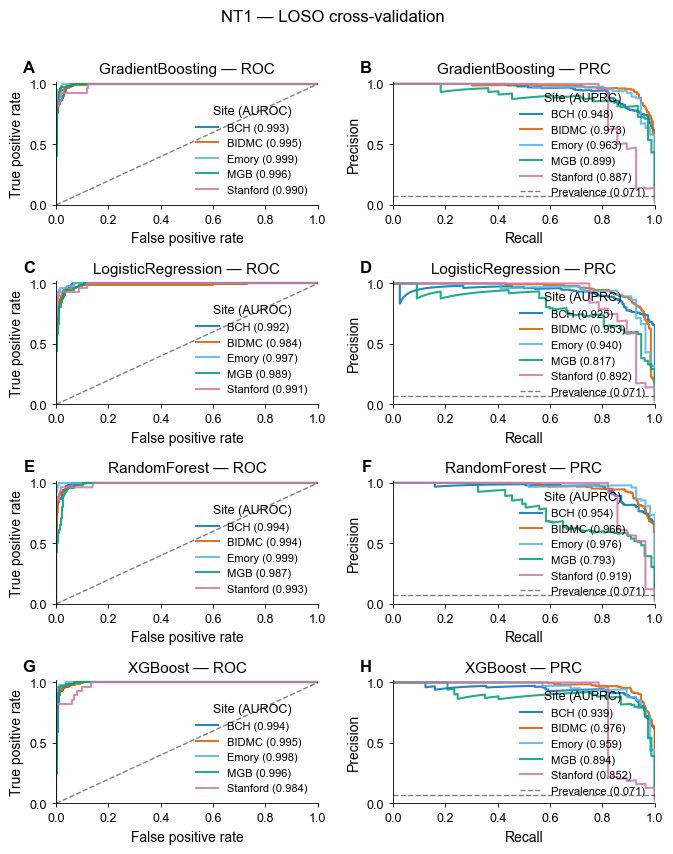

Saved: figure1b_nt2ih_roc_prc.png


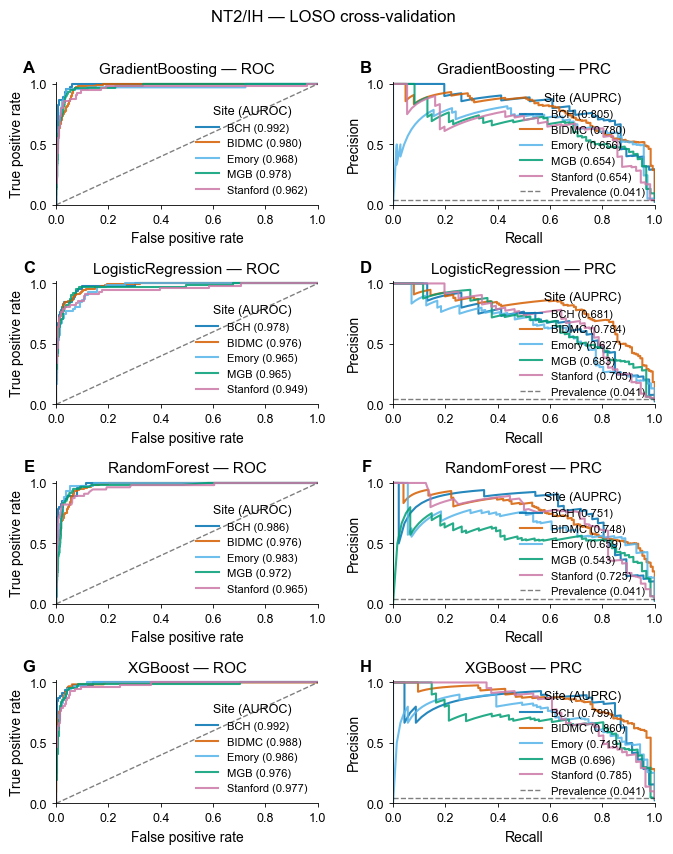

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

MANUSCRIPT_FIG_DIR = Path('../manuscript/figures')
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)

fig_name_map = {'nt1': 'figure1a_nt1_roc_prc.png', 'nt2ih': 'figure1b_nt2ih_roc_prc.png'}

# Panel labels: rows = models (alphabetical), cols = ROC/PRC
panel_labels_4x2 = [
    ['A', 'B'],
    ['C', 'D'],
    ['E', 'F'],
    ['G', 'H'],
]

for model_type in ['nt1', 'nt2ih']:
    model_comparison = all_models[model_type]
    feat = features.clone()
    if model_type == 'nt1':
        feat = feat.with_columns(
            pl.when(pl.col('annot') == 1).then(1).otherwise(0).alias('nt1')
        )
    elif model_type == 'nt2ih':
        feat = feat.with_columns(
            pl.when(pl.col('annot') == 2).then(1).otherwise(0).alias('nt2ih')
        )
    label = model_type_mapping[model_type]

    model_names = sorted(model_comparison.keys())
    n_models = len(model_names)

    # Height: 2.1in per row → 4 models = 8.4in (under 9.5in max)
    fig, axes = plt.subplots(n_models, 2, figsize=(6.875, 2.1 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)

    # Colorblind-safe site colors from pub_style
    site_color_map = {site_mapping[s]: SITE_COLORS[site_mapping[s]]
                      for s in sorted(list(model_comparison.values())[0].keys())}

    # Compute prevalence for PRC baseline (same across models)
    y_all = feat[model_type].to_numpy()
    prevalence = y_all.mean()

    for m_idx, model_name in enumerate(model_names):
        models = model_comparison[model_name]
        ax_roc = axes[m_idx, 0]
        ax_prc = axes[m_idx, 1]

        # Add panel labels
        add_panel_label(ax_roc, panel_labels_4x2[m_idx][0])
        add_panel_label(ax_prc, panel_labels_4x2[m_idx][1])

        for test_site in sorted(models.keys()):
            test_feat = feat.filter(pl.col('cohort') == test_site)
            X_test = test_feat.drop(['annot', 'cohort', 'id', 'date', model_type])
            y_test = test_feat[model_type].to_numpy()

            y_prob = models[test_site].predict_proba(X_test)[:, 1]
            site_label = site_mapping[test_site]
            color = SITE_COLORS[site_label]

            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            ax_roc.plot(fpr, tpr, color=color, alpha=0.85, linewidth=LINE_WIDTH,
                        label=f"{site_label} ({roc_auc:.3f})")

            precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
            pr_auc = auc(recall_vals, precision_vals)
            ax_prc.plot(recall_vals, precision_vals, color=color, alpha=0.85,
                        linewidth=LINE_WIDTH,
                        label=f"{site_label} ({pr_auc:.3f})")

        # ROC: chance line
        ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=REFERENCE_LINE_WIDTH, alpha=0.5)
        ax_roc.set_title(f'{model_name} — ROC')
        ax_roc.set_xlabel('False positive rate')
        ax_roc.set_ylabel('True positive rate')
        ax_roc.legend(title='Site (AUROC)', loc='lower right')
        ax_roc.set_xlim([0, 1])
        ax_roc.set_ylim([0, 1.02])

        # PRC: prevalence baseline
        ax_prc.axhline(prevalence, color='k', linestyle='--',
                       linewidth=REFERENCE_LINE_WIDTH, alpha=0.5,
                       label=f'Prevalence ({prevalence:.3f})')
        ax_prc.set_title(f'{model_name} — PRC')
        ax_prc.set_xlabel('Recall')
        ax_prc.set_ylabel('Precision')
        ax_prc.legend(title='Site (AUPRC)', loc='upper right')
        ax_prc.set_xlim([0, 1])
        ax_prc.set_ylim([0, 1.02])

    fig.suptitle(f'{label} — LOSO cross-validation', fontsize=FONT_SIZE_TITLE + 1,
                 y=1.01)
    plt.tight_layout()

    savefig(fig, str(MANUSCRIPT_FIG_DIR / fig_name_map[model_type]))
    print(f'Saved: {fig_name_map[model_type]}')

    plt.show()